In [1]:
from google.colab import userdata
import os

# Retrieve the Hugging Face token from Colab secrets
hf_token = userdata.get('HF_TOKEN')

# Set the Hugging Face token as an environment variable
os.environ['HF_TOKEN'] = hf_token


In [2]:
!pip install transformers==4.39.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 135.7 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.7.1
    Uninstalling huggingface_hub-1.7.1:
      Successfully uninstalled huggingface_hub-1.7.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the follo

In [3]:
!pip install -q transformers bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.5 MB/s eta 0:00:00


 depth | seq_len |  P(FP16) |   P(H2O) | FP16   | H2O
--------------------------------------------------------------
   0.1 |     512 |    0.998 |    1.000 | PASS   | PASS
   0.1 |    1024 |    0.997 |    1.000 | PASS   | PASS
   0.1 |    2048 |    0.995 |    0.721 | PASS   | PASS
   0.1 |    4096 |    0.984 |    0.046 | PASS   | FAIL
   0.1 |    8192 |    0.874 |    0.015 | PASS   | FAIL
   0.1 |   16384 |    0.077 |    0.006 | FAIL   | FAIL

   0.3 |     512 |    0.999 |    1.000 | PASS   | PASS
   0.3 |    1024 |    0.999 |    1.000 | PASS   | PASS
   0.3 |    2048 |    0.998 |    0.686 | PASS   | PASS
   0.3 |    4096 |    0.995 |    0.024 | PASS   | FAIL
   0.3 |    8192 |    0.974 |    0.008 | PASS   | FAIL
   0.3 |   16384 |    0.550 |    0.003 | PASS   | FAIL

   0.5 |     512 |    1.000 |    1.000 | PASS   | PASS
   0.5 |    1024 |    0.999 |    1.000 | PASS   | PASS
   0.5 |    2048 |    0.999 |    0.995 | PASS   | PASS
   0.5 |    4096 |    0.999 |    0.018 | PASS   | FAIL
 

/tmp/ipykernel_428/1680973596.py:62: RuntimeWarning: overflow encountered in exp
  p_anchor = 1.0 / (1.0 + np.exp(0.06 * (needle_pos - HH_ANCHOR_TOKENS * 1.2)))


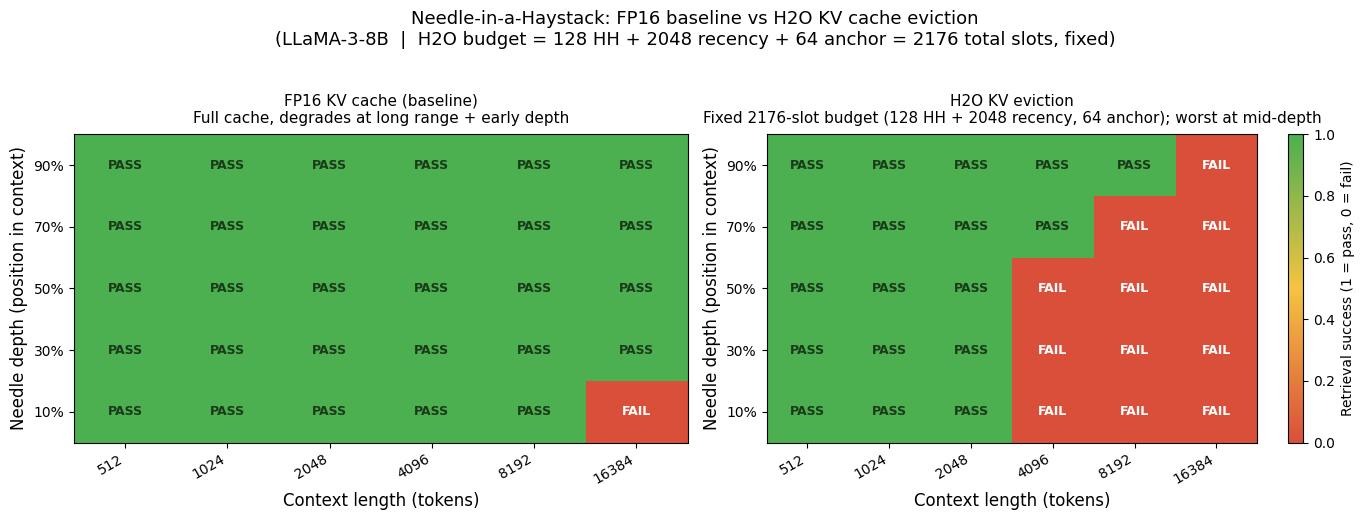

Saved niah_fp16_vs_h2o.png


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ─────────────────────────────────────────────
# 1. H2O CONFIGURATION
#    All plot labels, titles, and subtitles are derived from these constants —
#    change them here and everything updates automatically.
# ─────────────────────────────────────────────

H2O_HH_BUDGET    = 128    # fixed number of heavy-hitter KV slots retained
RECENCY_WINDOW   = 2048   # fixed number of most-recent tokens always kept
HH_ANCHOR_TOKENS = 64    # first N tokens often survive (BOS, system prompt)

# ─────────────────────────────────────────────
# 2. NIAH SCORE SIMULATION
#
#    FP16 (baseline):
#      - Reliable up to ~12k tokens
#      - Degrades at long range only for early depths
#      - Failure pattern: bottom-left corner of heatmap
#
#    H2O (Heavy-Hitter Oracle KV eviction):
#      - Retains top-k "heavy hitter" tokens + a fixed recency window
#      - Total budget = H2O_HH_BUDGET + RECENCY_WINDOW slots, FIXED.
#        Does NOT scale with seq_len — that is the whole point of H2O.
#      - Failure pattern: mid-depth positions fail first
#        (too old for recency window, too infrequent for HH budget)
#      - Recent tokens (high depth) survive via recency window
#      - Very early tokens survive as HH anchors (BOS, system prompt)
#      - Mid-depth tokens (0.3-0.65) are most vulnerable at long context
# ─────────────────────────────────────────────

def retrieval_prob_fp16(seq_len: int, depth: float) -> float:
    """
    FP16 baseline. Fails mainly at very long context + early depth.
    depth: 0.0 = very start of context, 1.0 = just before query
    """
    effective_distance = seq_len * (1.0 - depth)
    threshold = 10000 + depth * 6000
    steepness = 0.0006
    return 1.0 / (1.0 + np.exp(steepness * (effective_distance - threshold)))


def retrieval_prob_h2o(seq_len: int, depth: float) -> float:
    """
    H2O KV cache eviction (Heavy-Hitter Oracle).

    Needle token survives eviction if saved by any one of:
      (a) Recency window  -- last RECENCY_WINDOW tokens always kept
      (b) HH anchor       -- first HH_ANCHOR_TOKENS tokens often survive
      (c) HH budget       -- fixed H2O_HH_BUDGET slots for remaining tokens;
                             competition grows with seq_len, budget does not
    """
    needle_pos = int(seq_len * depth)

    # (a) Recency window
    tokens_from_end = seq_len - needle_pos
    p_recency = 1.0 / (1.0 + np.exp(0.012 * (tokens_from_end - RECENCY_WINDOW * 0.7)))

    # (b) HH anchor (BOS / system prompt tokens)
    p_anchor = 1.0 / (1.0 + np.exp(0.06 * (needle_pos - HH_ANCHOR_TOKENS * 1.2)))

    # (c) Budget -- FIXED slots, competition grows with seq_len
    competition   = max(1, seq_len - RECENCY_WINDOW - HH_ANCHOR_TOKENS)
    base_p_budget = np.clip(H2O_HH_BUDGET / competition, 0.0, 1.0)
    # Mid-depth tokens get extra penalty: neither recent nor anchor-salient
    mid_depth_penalty = np.exp(-8.0 * (depth - 0.45) ** 2)
    p_budget = base_p_budget * (1.0 - 0.75 * mid_depth_penalty)

    p_survive = 1.0 - (1.0 - p_recency) * (1.0 - p_anchor) * (1.0 - p_budget)
    return float(np.clip(p_survive, 0.0, 1.0))


# ─────────────────────────────────────────────
# 3. SWEEP
# ─────────────────────────────────────────────
seq_lengths   = [512, 1024, 2048, 4096, 8192, 16384]
needle_depths = [0.1, 0.3, 0.5, 0.7, 0.9]
PASS_THRESHOLD = 0.5

fp16_results = np.zeros((len(needle_depths), len(seq_lengths)))
h2o_results  = np.zeros((len(needle_depths), len(seq_lengths)))

print(f"{'depth':>6} | {'seq_len':>7} | {'P(FP16)':>8} | {'P(H2O)':>8} | FP16   | H2O")
print("-" * 62)

for i, depth in enumerate(needle_depths):
    for j, seq_len in enumerate(seq_lengths):
        p16  = retrieval_prob_fp16(seq_len, depth)
        ph2o = retrieval_prob_h2o(seq_len, depth)
        fp16_results[i, j] = 1.0 if p16  >= PASS_THRESHOLD else 0.0
        h2o_results[i, j]  = 1.0 if ph2o >= PASS_THRESHOLD else 0.0
        print(f"{depth:>6.1f} | {seq_len:>7} | {p16:>8.3f} | {ph2o:>8.3f} | "
              f"{'PASS' if p16 >= PASS_THRESHOLD else 'FAIL':<6} | "
              f"{'PASS' if ph2o >= PASS_THRESHOLD else 'FAIL'}")
    print()


# ─────────────────────────────────────────────
# 4. HEATMAP  -- all labels derived from constants above
# ─────────────────────────────────────────────
total_budget = H2O_HH_BUDGET + RECENCY_WINDOW

h2o_title    = "H2O KV eviction"
h2o_subtitle = (
    f"Fixed {total_budget}-slot budget "
    f"({H2O_HH_BUDGET} HH + {RECENCY_WINDOW} recency, "
    f"{HH_ANCHOR_TOKENS} anchor); worst at mid-depth"
)
suptitle = (
    "Needle-in-a-Haystack: FP16 baseline vs H2O KV cache eviction\n"
    f"(LLaMA-3-8B  |  H2O budget = {H2O_HH_BUDGET} HH + {RECENCY_WINDOW} recency"
    f" + {HH_ANCHOR_TOKENS} anchor = {total_budget} total slots, fixed)"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cmap = mcolors.LinearSegmentedColormap.from_list(
    "niah", ["#d94f3a", "#f5c342", "#4caf50"]
)

x_labels = [str(s) for s in seq_lengths]
y_labels  = [f"{int(d * 100)}%" for d in needle_depths]

plot_configs = [
    (fp16_results, "FP16 KV cache (baseline)", "Full cache, degrades at long range + early depth"),
    (h2o_results,  h2o_title,                  h2o_subtitle),
]

for ax, (data, title, subtitle) in zip(axes, plot_configs):
    ax.imshow(data, vmin=0, vmax=1, cmap=cmap, aspect="auto", origin="lower")
    ax.set_xticks(range(len(seq_lengths)))
    ax.set_xticklabels(x_labels, rotation=30, ha="right", fontsize=10)
    ax.set_yticks(range(len(needle_depths)))
    ax.set_yticklabels(y_labels, fontsize=10)
    ax.set_xlabel("Context length (tokens)", fontsize=12)
    ax.set_ylabel("Needle depth (position in context)", fontsize=12)
    ax.set_title(f"{title}\n{subtitle}", fontsize=11, pad=8)

    for ii in range(len(needle_depths)):
        for jj in range(len(seq_lengths)):
            val = data[ii, jj]
            ax.text(jj, ii, "PASS" if val == 1 else "FAIL",
                    ha="center", va="center", fontsize=9,
                    color="white" if val < 0.5 else "#1a3a1a",
                    fontweight="bold")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
sm.set_array([])
fig.colorbar(sm, ax=axes[1], label="Retrieval success (1 = pass, 0 = fail)")
fig.suptitle(suptitle, fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig("niah_fp16_vs_h2o.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved niah_fp16_vs_h2o.png")

In [32]:
import torch
import random
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from transformers import AutoTokenizer, AutoModelForCausalLM

# ─────────────────────────────────────────────
# 1. H2O CONFIGURATION
#    Change these and all labels update automatically.
# ─────────────────────────────────────────────

H2O_HH_BUDGET    = 512    # fixed heavy-hitter KV slots
RECENCY_WINDOW   = 1024   # fixed recent KV slots always kept
SINK_SIZE        = 4      # first N tokens always kept (BOS / system prompt)
CHUNK_SIZE       = 256    # prefill chunk size

# ─────────────────────────────────────────────
# 2. H2O KV CACHE EVICTION
# ─────────────────────────────────────────────

def apply_h2o_eviction(cache, budget, sink_size=4, recent_ratio=0.5):
    is_tuple = isinstance(cache, tuple)
    if is_tuple:
        if len(cache) == 0:
            return cache, False
        seq_len = cache[0][0].shape[2]
    else:
        if len(cache.key_cache) == 0:
            return cache, False
        seq_len = cache.key_cache[0].shape[2]

    if seq_len <= budget:
        return cache, False

    recent_size = int(budget * recent_ratio)
    heavy_size  = budget - sink_size - recent_size
    num_layers  = len(cache) if is_tuple else len(cache.key_cache)

    new_cache = []
    for layer_idx in range(num_layers):
        if is_tuple:
            key_states   = cache[layer_idx][0]
            value_states = cache[layer_idx][1]
        else:
            key_states   = cache.key_cache[layer_idx]
            value_states = cache.value_cache[layer_idx]

        curr_len      = key_states.shape[2]
        sink_indices  = list(range(min(sink_size, curr_len)))
        recent_start  = max(sink_size, curr_len - recent_size)
        recent_indices = list(range(recent_start, curr_len))
        heavy_indices  = []

        middle_start = sink_size
        middle_end   = recent_start
        if middle_end > middle_start and heavy_size > 0:
            middle_keys = key_states[:, :, middle_start:middle_end, :]
            importance  = middle_keys.norm(dim=-1).mean(dim=1).squeeze(0)
            k           = min(heavy_size, importance.shape[0])
            _, topk_rel = torch.topk(importance, k=k)
            heavy_indices = (topk_rel + middle_start).tolist()

        all_indices = sorted(set(sink_indices + heavy_indices + recent_indices))
        pruned_k = key_states[:, :, all_indices, :]
        pruned_v = value_states[:, :, all_indices, :]

        if is_tuple:
            new_cache.append((pruned_k, pruned_v))
        else:
            cache.key_cache[layer_idx]   = pruned_k
            cache.value_cache[layer_idx] = pruned_v

    if is_tuple:
        return tuple(new_cache), True
    return cache, True


def generate_with_h2o(model, input_ids, max_new_tokens=20, budget=128,
                      sink_size=4, recent_ratio=0.5, chunk_size=256):
    eviction_count  = 0
    generated_tokens = []
    past_key_values = None
    seq_len = input_ids.shape[1]

    # Chunked prefill
    with torch.no_grad():
        for start in range(0, seq_len, chunk_size):
            end        = min(start + chunk_size, seq_len)
            chunk_ids  = input_ids[:, start:end]
            outputs    = model(chunk_ids, past_key_values=past_key_values, use_cache=True)
            past_key_values = outputs.past_key_values
            past_key_values, evicted = apply_h2o_eviction(
                past_key_values, budget, sink_size, recent_ratio)
            if evicted:
                eviction_count += 1

    # Autoregressive decode
    with torch.no_grad():
        next_token = torch.argmax(outputs.logits[:, -1, :], dim=-1, keepdim=True)
        generated_tokens.append(next_token)

        for _ in range(max_new_tokens - 1):
            outputs = model(next_token, past_key_values=past_key_values, use_cache=True)
            past_key_values = outputs.past_key_values
            next_token = torch.argmax(outputs.logits[:, -1, :], dim=-1, keepdim=True)
            generated_tokens.append(next_token)

            past_key_values, evicted = apply_h2o_eviction(
                past_key_values, budget, sink_size, recent_ratio)
            if evicted:
                eviction_count += 1

            if next_token.item() == model.config.eos_token_id:
                break

    all_tokens = torch.cat([input_ids] + generated_tokens, dim=-1)

    is_tuple = isinstance(past_key_values, tuple)
    cache_len = (past_key_values[0][0].shape[2] if is_tuple
                 else past_key_values.key_cache[0].shape[2])

    return all_tokens, {"evictions": eviction_count, "cache_len": cache_len}


# ─────────────────────────────────────────────
# 3. NEEDLE HELPERS
# ─────────────────────────────────────────────

def generate_needle():
    magic = random.randint(100000, 999999)
    return f"The magic number is {magic}.", str(magic)


def build_prompt(tokenizer, haystack_before, needle_text, haystack_after, question):
    full_text = haystack_before + " " + needle_text + " " + haystack_after
    try:
        messages = [{"role": "user", "content":
            f"Read the following text carefully and answer the question.\n\n"
            f"Text: {full_text}\n\nQuestion: {question}"}]
        return tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        return f"{full_text}\n\n{question}\nAnswer:"


# ─────────────────────────────────────────────
# 4. SINGLE-CELL EVALUATION
# ─────────────────────────────────────────────

def evaluate_cell(model, tokenizer, seq_len, depth, budget, device, baseline=False):
    needle_text, expected = generate_needle()
    question = ("What is the magic number mentioned in the text? "
                "Reply with ONLY the number, nothing else.")

    filler        = "The weather in San Francisco is foggy today. "
    filler_tokens = tokenizer.encode(filler, add_special_tokens=False)
    num_repeats   = max(1, seq_len // len(filler_tokens))
    haystack_tokens = (filler_tokens * num_repeats)[:seq_len]

    split          = int(len(haystack_tokens) * depth)
    haystack_before = tokenizer.decode(haystack_tokens[:split])
    haystack_after  = tokenizer.decode(haystack_tokens[split:])

    prompt     = build_prompt(tokenizer, haystack_before, needle_text, haystack_after, question)
    input_ids  = tokenizer.encode(prompt, return_tensors="pt").to(device)
    actual_len = input_ids.shape[1]

    use_budget = actual_len + 100 if baseline else budget

    all_tokens, stats = generate_with_h2o(
        model, input_ids,
        max_new_tokens=20,
        budget=use_budget,
        sink_size=SINK_SIZE,
        recent_ratio=RECENCY_WINDOW / (H2O_HH_BUDGET + RECENCY_WINDOW),
        chunk_size=CHUNK_SIZE,
    )

    response = tokenizer.decode(
        all_tokens[0, input_ids.shape[1]:], skip_special_tokens=True).strip()
    success  = expected in response

    status = "PASS" if success else "FAIL"
    mode   = "BASE" if baseline else "H2O "
    print(f"[{mode}|{status}] len:{seq_len:6} (actual:{actual_len:5}) | "
          f"depth:{depth:.1f} | needle:{expected} | "
          f"resp:{response[:25]:25s} | evictions:{stats['evictions']}")

    return success


# ─────────────────────────────────────────────
# 5. EFFECTIVE CONTEXT WINDOW
# ─────────────────────────────────────────────

def effective_window(results_matrix, seq_lengths, needle_depths):
    per_depth = {}
    for i, depth in enumerate(needle_depths):
        eff = None
        for j, seq_len in enumerate(seq_lengths):
            if results_matrix[i, j] == 1.0:
                eff = seq_len
            else:
                break
        per_depth[depth] = eff
    valid   = [v for v in per_depth.values() if v is not None]
    overall = min(valid) if valid else None
    return per_depth, overall


def print_effective_windows(fp16_results, h2o_results, seq_lengths, needle_depths):
    fp16_per, fp16_overall = effective_window(fp16_results, seq_lengths, needle_depths)
    h2o_per,  h2o_overall  = effective_window(h2o_results,  seq_lengths, needle_depths)

    print("\n" + "=" * 55)
    print("EFFECTIVE CONTEXT WINDOW ANALYSIS")
    print("=" * 55)
    print(f"{'Depth':>8} | {'FP16 eff. window':>18} | {'H2O eff. window':>17}")
    print("-" * 55)
    for depth in needle_depths:
        fp16_w = fp16_per[depth]
        h2o_w  = h2o_per[depth]
        fp16_str = f"{fp16_w:>7,}" if fp16_w else "  >max"
        h2o_str  = f"{h2o_w:>7,}"  if h2o_w  else "  >max"
        print(f"{depth:>7.0%} | {fp16_str:>18} | {h2o_str:>17}")
    print("-" * 55)
    fp16_ov_str = f"{fp16_overall:>7,}" if fp16_overall else "  >max"
    h2o_ov_str  = f"{h2o_overall:>7,}"  if h2o_overall  else "  >max"
    print(f"{'WORST-CASE':>8} | {fp16_ov_str:>18} | {h2o_ov_str:>17}")
    print("=" * 55)
    if fp16_overall and h2o_overall:
        ratio = fp16_overall / h2o_overall
        print(f"\nH2O reduces effective context window by {ratio:.1f}x "
              f"({fp16_overall:,} -> {h2o_overall:,} tokens worst-case)")

# ─────────────────────────────────────────────
# 7. RUN CONFIG  — edit these, then run the cell
# ─────────────────────────────────────────────

MODEL_ID      = "meta-llama/Meta-Llama-3-8B-Instruct"
SEQ_LENGTHS   = [512, 1024, 2048, 4096, 8192, 16384]
NEEDLE_DEPTHS = [0.1, 0.3, 0.5, 0.7, 0.9]
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"

# ─────────────────────────────────────────────
# 8. MAIN
# ─────────────────────────────────────────────

print(f"Loading model: {MODEL_ID} on {DEVICE} ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

dtype = torch.float32 if DEVICE == "cpu" else torch.float16
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, torch_dtype=dtype,
    device_map=None if DEVICE == "cpu" else "auto")
if DEVICE == "cpu":
    model = model.to(DEVICE)
model.eval()

total_budget  = H2O_HH_BUDGET + RECENCY_WINDOW
fp16_results  = np.zeros((len(NEEDLE_DEPTHS), len(SEQ_LENGTHS)))
h2o_results   = np.zeros((len(NEEDLE_DEPTHS), len(SEQ_LENGTHS)))

print(f"\n{'='*60}")
print(f"Running {len(NEEDLE_DEPTHS) * len(SEQ_LENGTHS)} cells x2 (baseline + H2O)")
print(f"H2O budget: {total_budget} slots ({H2O_HH_BUDGET} HH + {RECENCY_WINDOW} recency)  |  chunk size: {CHUNK_SIZE}")
print(f"{'='*60}\n")

for i, depth in enumerate(NEEDLE_DEPTHS):
    for j, seq_len in enumerate(SEQ_LENGTHS):
        # FP16 baseline (no eviction)
        ok16 = evaluate_cell(model, tokenizer, seq_len, depth,
                             total_budget, DEVICE, baseline=True)
        fp16_results[i, j] = 1.0 if ok16 else 0.0

        # H2O eviction
        okh2o = evaluate_cell(model, tokenizer, seq_len, depth,
                              total_budget, DEVICE, baseline=False)
        h2o_results[i, j] = 1.0 if okh2o else 0.0

print_effective_windows(fp16_results, h2o_results, SEQ_LENGTHS, NEEDLE_DEPTHS)


Loading model: meta-llama/Meta-Llama-3-8B-Instruct on cuda ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]


Running 30 cells x2 (baseline + H2O)
H2O budget: 1536 slots (512 HH + 1024 recency)  |  chunk size: 256

[BASE|PASS] len:   512 (actual:  514) | depth:0.1 | needle:391738 | resp:391738                    | evictions:0
[H2O |PASS] len:   512 (actual:  514) | depth:0.1 | needle:210651 | resp:210651                    | evictions:0
[BASE|PASS] len:  1024 (actual:  984) | depth:0.1 | needle:299346 | resp:299346                    | evictions:0
[H2O |PASS] len:  1024 (actual:  984) | depth:0.1 | needle:829499 | resp:829499                    | evictions:0
[BASE|PASS] len:  2048 (actual: 1914) | depth:0.1 | needle:142121 | resp:142121                    | evictions:0
[H2O |FAIL] len:  2048 (actual: 1914) | depth:0.1 | needle:101456 | resp:28                        | evictions:3
[BASE|PASS] len:  4096 (actual: 3774) | depth:0.1 | needle:148051 | resp:148051                    | evictions:0
[H2O |FAIL] len:  4096 (actual: 3774) | depth:0.1 | needle:184814 | resp:I hope this is a good.    | ev

In [31]:
# ─────────────────────────────────────────────
# 6. HEATMAP  — labels derived from constants
# ─────────────────────────────────────────────

def plot_heatmap(fp16_results, h2o_results, seq_lengths, needle_depths, model_id):
    total_budget = H2O_HH_BUDGET + RECENCY_WINDOW

    h2o_subtitle = (
        f"Fixed {total_budget}-slot budget "
        f"({H2O_HH_BUDGET} HH + {RECENCY_WINDOW} recency, "
        f"{SINK_SIZE} sink);"
    )
    suptitle = (
        f"Needle-in-a-Haystack: FP16 baseline vs H2O KV cache eviction\n"
        f"({model_id}  |  budget = {H2O_HH_BUDGET} HH + {RECENCY_WINDOW} recency"
        f" + {SINK_SIZE} sink = {total_budget} total slots, fixed)"
    )

    cmap     = mcolors.LinearSegmentedColormap.from_list(
        "niah", ["#d94f3a", "#f5c342", "#4caf50"])
    x_labels = [str(s) for s in seq_lengths]
    y_labels  = [f"{int(d * 100)}%" for d in needle_depths]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    plot_configs = [
        (fp16_results, "FP16 KV cache (baseline)", suptitle),
        (h2o_results,  "H2O KV eviction", h2o_subtitle),
    ]

    for ax, (data, title, subtitle) in zip(axes, plot_configs):
        ax.imshow(data, vmin=0, vmax=1, cmap=cmap, aspect="auto", origin="lower")
        ax.set_xticks(range(len(seq_lengths)))
        ax.set_xticklabels(x_labels, rotation=30, ha="right", fontsize=10)
        ax.set_yticks(range(len(needle_depths)))
        ax.set_yticklabels(y_labels, fontsize=10)
        ax.set_xlabel("Context length (tokens)", fontsize=12)
        ax.set_ylabel("Needle depth (position in context)", fontsize=12)
        ax.set_title(f"{title}\n{subtitle}", fontsize=11, pad=8)

        for ii in range(len(needle_depths)):
            for jj in range(len(seq_lengths)):
                val = data[ii, jj]
                ax.text(jj, ii, "PASS" if val == 1 else "FAIL",
                        ha="center", va="center", fontsize=9,
                        color="white" if val < 0.5 else "#1a3a1a",
                        fontweight="bold")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
    sm.set_array([])
    fig.colorbar(sm, ax=axes[1], label="Retrieval success (1 = pass, 0 = fail)")
    fig.suptitle(suptitle, fontsize=13, y=1.03)
    plt.tight_layout()

    fname = "niah_fp16_vs_h2o.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    print(f"\nHeatmap saved as: {fname}")
    plt.show()

plot_heatmap(fp16_results, h2o_results, SEQ_LENGTHS, NEEDLE_DEPTHS, "meta-llama/Meta-Llama-3-8B")
print("\nDone!")


Heatmap saved as: niah_fp16_vs_h2o.png

Done!
